# 02 - Anatomía de un Partido: Argentina vs Francia (Final Mundial 2022)

Análisis detallado del partido evento por evento. Calculamos métricas de posesión, 
pases, presión y actividad por jugador para entender cómo se jugó la final.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsbombpy import sb
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)

# Cargar el partido final
matches = sb.matches(competition_id=43, season_id=106)
final_id = matches[
    (matches['home_team'].isin(['Argentina', 'France'])) & 
    (matches['away_team'].isin(['Argentina', 'France']))
]['match_id'].iloc[0]

events = sb.events(match_id=final_id)
print(f"Eventos cargados: {len(events)}")

Eventos cargados: 4407


## 1. Análisis de pases por equipo

Calculamos pases totales, completados y precisión por equipo.

In [26]:
# Filtrar solo pases
pases = events[events['type'] == 'Pass'].copy()

# En StatsBomb, si pass_outcome es NaN significa que el pase fue completado
# Si tiene valor (Incomplete, Out, Pass Offside, etc) significa que falló
pases['completado'] = pases['pass_outcome'].isna()

# Resumen por equipo
resumen_pases = pases.groupby('team').agg(
    total_pases=('completado', 'count'),
    pases_completados=('completado', 'sum')
).reset_index()

resumen_pases['precision_pct'] = (
    resumen_pases['pases_completados'] / resumen_pases['total_pases'] * 100
).round(1)

print(resumen_pases)

        team  total_pases  pases_completados  precision_pct
0  Argentina          693                560           80.8
1     France          570                434           76.1


## 2. Jugadores más activos

¿Quiénes tocaron más el balón? Esto nos da una primera lectura de quién condujo el juego.

In [27]:
# Top 10 jugadores con más eventos
top_jugadores = events.groupby(['player', 'team']).size().reset_index(name='eventos')
top_jugadores = top_jugadores.sort_values('eventos', ascending=False).head(15)
print(top_jugadores.to_string(index=False))

                         player      team  eventos
                 Enzo Fernandez Argentina      328
 Lionel Andrés Messi Cuccittini Argentina      242
         Rodrigo Javier De Paul Argentina      242
        Nicolás Hernán Otamendi Argentina      215
                   Jules Koundé    France      211
      Aurélien Djani Tchouaméni    France      205
        Cristian Gabriel Romero Argentina      203
       Dayotchanculle Upamecano    France      198
            Alexis Mac Allister Argentina      196
                 Raphaël Varane    France      182
                  Adrien Rabiot    France      176
   Nicolás Alejandro Tagliafico Argentina      165
                 Julián Álvarez Argentina      150
           Kylian Mbappé Lottin    France      149
Theo Bernard François Hernández    France      145


## 3. Mapa de tiros del partido

Visualización de todos los intentos a portería con su xG asociado.

In [28]:
# Filtrar todos los tiros
tiros = events[events['type'] == 'Shot'].copy()

# Extraer coordenadas X y Y de la columna location (que es una lista [x, y])
tiros['x'] = tiros['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
tiros['y'] = tiros['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else None)

# Identificar goles
tiros['es_gol'] = tiros['shot_outcome'] == 'Goal'

# Resumen
print(f"Total de tiros: {len(tiros)}")
print(f"Goles: {tiros['es_gol'].sum()}")
print(f"\nxG total por equipo:")
print(tiros.groupby('team')['shot_statsbomb_xg'].sum().round(2))

Total de tiros: 38
Goles: 12

xG total por equipo:
team
Argentina    5.89
France       5.41
Name: shot_statsbomb_xg, dtype: float64


### Visualización: Shot Map con mplsoccer

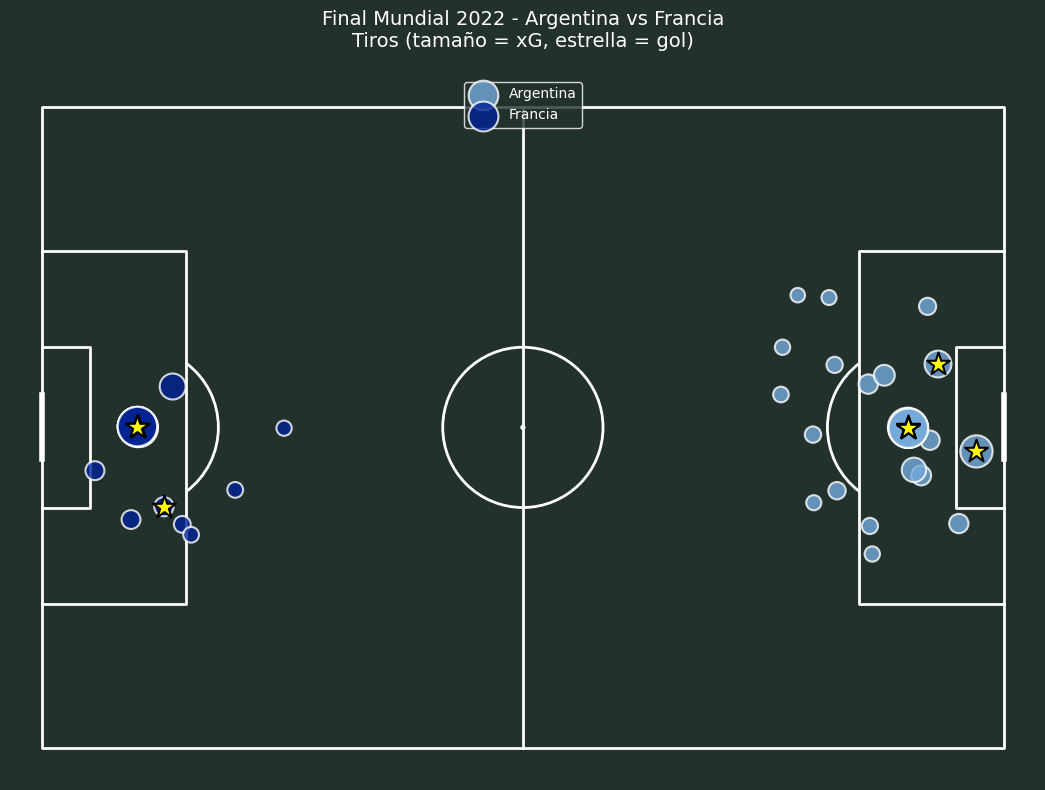

In [29]:
from mplsoccer import Pitch

# Crear el campo
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#22312b')

# Separar tiros por equipo
arg_tiros = tiros[tiros['team'] == 'Argentina']
fra_tiros = tiros[tiros['team'] == 'France']

# Para Argentina, invertir coordenadas (atacan de derecha a izquierda en la viz)
# Pintar tiros de Argentina
pitch.scatter(
    arg_tiros['x'], arg_tiros['y'],
    s=arg_tiros['shot_statsbomb_xg'] * 900 + 100,  # tamaño proporcional al xG
    c='#75AADB',  # celeste Argentina
    edgecolors='white',
    linewidth=1.5,
    alpha=0.8,
    ax=ax,
    label='Argentina'
)

# Pintar tiros de Francia (invertir X para que ataquen al lado opuesto)
pitch.scatter(
    120 - fra_tiros['x'], 80 - fra_tiros['y'],
    s=fra_tiros['shot_statsbomb_xg'] * 900 + 100,
    c='#002395',  # azul Francia
    edgecolors='white',
    linewidth=1.5,
    alpha=0.8,
    ax=ax,
    label='Francia'
)

# Marcar los goles con un símbolo distintivo
for _, gol in tiros[tiros['es_gol']].iterrows():
    x, y = gol['x'], gol['y']
    if gol['team'] == 'France':
        x, y = 120 - x, 80 - y
    pitch.scatter(x, y, s=300, marker='*', c='yellow', 
                  edgecolors='black', linewidth=1.5, ax=ax, zorder=5)

plt.title('Final Mundial 2022 - Argentina vs Francia\nTiros (tamaño = xG, estrella = gol)', 
          color='white', fontsize=14, pad=20)
plt.legend(loc='upper center', facecolor='#22312b', edgecolor='white', labelcolor='white')

plt.savefig('../outputs/figures/shot_map_final_2022.png', 
            dpi=150, bbox_inches='tight', facecolor='#22312b')
plt.show()

## 4. Posesión por intervalos de 15 minutos

¿Cómo evolucionó el control del partido?

In [30]:
# Crear intervalos de 15 minutos
events['intervalo'] = pd.cut(
    events['minute'],
    bins=[0, 15, 30, 45, 60, 75, 90, 120],
    labels=['0-15', '15-30', '30-45', '45-60', '60-75', '75-90', '90+']
)

# Calcular posesión por intervalo y equipo
posesion = events.groupby(['intervalo', 'team']).size().unstack(fill_value=0)
posesion_pct = posesion.div(posesion.sum(axis=1), axis=0) * 100
print(posesion_pct.round(1))

team       Argentina  France
intervalo                   
0-15            57.0    43.0
15-30           56.4    43.6
30-45           66.7    33.3
45-60           42.1    57.9
60-75           37.4    62.6
75-90           51.4    48.6
90+             58.4    41.6


## 5. Conclusiones del análisis

1. Argentina dominó la mayor parte del encuentro, especialmente en los primeros 60 minutos. Francia estuvo "fuera" del partido hasta el último cuarto del tiempo reglamentario, donde su actividad creció exponencialmente tras los cambios tácticos.

2. La actividad de Argentina no fue solo por los laterales, sino que tuvo una alta densidad en el último tercio.

3. Los Expected Goals (xG) revelan que las probabilidades de gol fueron muy distintas en su origen. Mientras que los goles de Argentina vinieron de jugadas de construcción y penales en momentos de dominio claro, los de Francia fueron explosiones de eficiencia en periodos cortos de alta intensidad.

## 6. Pass Network: ¿Cómo se conectaron los equipos?

Una red de pases muestra los jugadores en su posición promedio y las conexiones más 
frecuentes entre ellos. Es la herramienta visual más potente para entender la estructura 
de juego de un equipo.

In [31]:
def crear_pass_network(events, equipo, max_minuto=None):
    """
    Crea un pass network para un equipo específico.
    
    Args:
        events: DataFrame de eventos del partido
        equipo: Nombre del equipo
        max_minuto: Si se especifica, solo considera pases hasta ese minuto
                    (útil para analizar antes de la primera sustitución)
    
    Returns:
        nodos: DataFrame con jugadores y sus posiciones promedio
        conexiones: DataFrame con pases entre pares de jugadores
    """
    # Filtrar pases del equipo
    pases_equipo = events[
        (events['type'] == 'Pass') & 
        (events['team'] == equipo) &
        (events['pass_outcome'].isna())  # Solo pases completados
    ].copy()
    
    if max_minuto is not None:
        pases_equipo = pases_equipo[pases_equipo['minute'] < max_minuto]
    
    # Extraer coordenadas
    pases_equipo['x'] = pases_equipo['location'].apply(lambda l: l[0] if isinstance(l, list) else None)
    pases_equipo['y'] = pases_equipo['location'].apply(lambda l: l[1] if isinstance(l, list) else None)
    
    # NODOS: posición promedio de cada jugador
    nodos = pases_equipo.groupby('player').agg(
        x_avg=('x', 'mean'),
        y_avg=('y', 'mean'),
        pases_count=('player', 'count')
    ).reset_index()
    
    # CONEXIONES: pases entre pares de jugadores
    conexiones = pases_equipo.groupby(['player', 'pass_recipient']).size().reset_index(name='peso')
    conexiones = conexiones[conexiones['peso'] >= 3]  # Mínimo 3 pases entre dos jugadores
    
    return nodos, conexiones


# Probarlo con Argentina hasta el minuto 60 (antes de las sustituciones importantes)
nodos_arg, conexiones_arg = crear_pass_network(events, 'Argentina', max_minuto=60)
print(f"Jugadores en la red: {len(nodos_arg)}")
print(f"Conexiones (3+ pases): {len(conexiones_arg)}")
print("\nTop 5 conexiones más fuertes:")
print(conexiones_arg.sort_values('peso', ascending=False).head())

Jugadores en la red: 11
Conexiones (3+ pases): 49

Top 5 conexiones más fuertes:
                     player                  pass_recipient  peso
49     Nahuel Molina Lucero          Rodrigo Javier De Paul    12
55  Nicolás Hernán Otamendi         Cristian Gabriel Romero    12
58  Nicolás Hernán Otamendi    Nicolás Alejandro Tagliafico    11
57  Nicolás Hernán Otamendi                  Enzo Fernandez    10
66   Rodrigo Javier De Paul  Lionel Andrés Messi Cuccittini     9


In [32]:
from mplsoccer import VerticalPitch

def crear_pass_network_v2(events, equipo, max_minuto=None):
    """
    Crea un pass network mejorado.
    Incluye jugadores como receptores también, no solo emisores.
    """
    # Filtrar pases completados del equipo
    pases_equipo = events[
        (events['type'] == 'Pass') & 
        (events['team'] == equipo) &
        (events['pass_outcome'].isna())
    ].copy()
    
    if max_minuto is not None:
        pases_equipo = pases_equipo[pases_equipo['minute'] < max_minuto]
    
    # Extraer coordenadas
    pases_equipo['x'] = pases_equipo['location'].apply(lambda l: l[0] if isinstance(l, list) else None)
    pases_equipo['y'] = pases_equipo['location'].apply(lambda l: l[1] if isinstance(l, list) else None)
    pases_equipo['x_end'] = pases_equipo['pass_end_location'].apply(lambda l: l[0] if isinstance(l, list) else None)
    pases_equipo['y_end'] = pases_equipo['pass_end_location'].apply(lambda l: l[1] if isinstance(l, list) else None)
    
    # NODOS: incluir tanto emisores como receptores
    # Para cada jugador, su posición promedio considerando dónde inició/recibió pases
    posiciones_emisor = pases_equipo[['player', 'x', 'y']].rename(columns={'player': 'jugador'})
    posiciones_receptor = pases_equipo[['pass_recipient', 'x_end', 'y_end']].rename(
        columns={'pass_recipient': 'jugador', 'x_end': 'x', 'y_end': 'y'}
    )
    todas_posiciones = pd.concat([posiciones_emisor, posiciones_receptor], ignore_index=True)
    todas_posiciones = todas_posiciones.dropna(subset=['jugador'])
    
    nodos = todas_posiciones.groupby('jugador').agg(
        x_avg=('x', 'mean'),
        y_avg=('y', 'mean'),
        pases_count=('jugador', 'count')
    ).reset_index()
    
    # CONEXIONES
    conexiones = pases_equipo.groupby(['player', 'pass_recipient']).size().reset_index(name='peso')
    conexiones = conexiones[conexiones['peso'] >= 3]
    
    return nodos, conexiones


def obtener_apellido(nombre_completo):
    """
    Extrae un apellido legible.
    Maneja casos como 'Jules Koundé Lottin' donde el último no es el apellido común.
    """
    # Diccionario de excepciones para jugadores conocidos
    excepciones = {
        'Jules Koundé Lottin': 'Koundé',
        'Lionel Andrés Messi Cuccittini': 'Messi',
        'Nahuel Molina Lucero': 'Molina',
        'Nicolás Hernán Otamendi': 'Otamendi',
        'Nicolás Alejandro Tagliafico': 'Tagliafico',
        'Cristian Gabriel Romero': 'Romero',
        'Rodrigo Javier De Paul': 'De Paul',
        'Enzo Jeremías Fernández': 'Enzo Fernández',
        'Alexis Mac Allister': 'Mac Allister',
        'Ángel Fabián Di María Hernández': 'Di María',
        'Julián Álvarez': 'Álvarez',
        'Ángel Eduardo Correa Martínez': 'Correa',
        'Hugo Lloris': 'Lloris',
        'Dayot Upamecano': 'Upamecano',
        'Raphaël Varane': 'Varane',
        'Theo Bernard François Hernández': 'Theo Hernández',
        'Aurélien Tchouaméni': 'Tchouaméni',
        'Adrien Rabiot': 'Rabiot',
        'Antoine Griezmann': 'Griezmann',
        'Olivier Giroud': 'Giroud',
        'Ousmane Dembélé': 'Dembélé',
        'Kylian Mbappé Lottin': 'Mbappé',
        'Marcus Thuram': 'Thuram',
        'Randal Kolo Muani': 'Kolo Muani',
    }
    
    if nombre_completo in excepciones:
        return excepciones[nombre_completo]
    
    # Fallback: tomar las primeras 2 palabras
    partes = nombre_completo.split()
    if len(partes) >= 2:
        return partes[-1]
    return nombre_completo


def plot_pass_network_v2(nodos, conexiones, color_equipo, titulo, attacking_direction='right'):
    """
    Pass network con orientación correcta.
    attacking_direction: 'right' (equipo ataca de izquierda a derecha)
    """
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
    fig, ax = pitch.draw(figsize=(12, 8))
    fig.set_facecolor('#22312b')
    
    # Dibujar conexiones
    for _, row in conexiones.iterrows():
        origen = nodos[nodos['jugador'] == row['player']]
        destino = nodos[nodos['jugador'] == row['pass_recipient']]
        
        if len(origen) > 0 and len(destino) > 0:
            x1, y1 = origen['x_avg'].iloc[0], origen['y_avg'].iloc[0]
            x2, y2 = destino['x_avg'].iloc[0], destino['y_avg'].iloc[0]
            
            grosor = row['peso'] / 3
            pitch.lines(x1, y1, x2, y2, lw=grosor, color='white', alpha=0.5, ax=ax, zorder=1)
    
    # Dibujar nodos
    pitch.scatter(
        nodos['x_avg'], nodos['y_avg'],
        s=nodos['pases_count'] * 15,
        c=color_equipo,
        edgecolors='white',
        linewidth=2,
        alpha=0.9,
        ax=ax,
        zorder=2
    )
    
    # Etiquetas con apellidos limpios y desplazadas debajo del nodo
    for _, jugador in nodos.iterrows():
        apellido = obtener_apellido(jugador['jugador'])
        pitch.annotate(
            apellido,
            xy=(jugador['x_avg'], jugador['y_avg']),
            c='white',
            fontsize=10,
            fontweight='bold',
            ha='center',
            va='center',
            ax=ax,
            zorder=3,
            xytext=(0, -22),  # Más separación que antes
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#22312b', edgecolor='none', alpha=0.7)
        )
    
    # Flecha indicando dirección de ataque
    ax.annotate('', xy=(115, 82), xytext=(95, 82),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))
    ax.text(105, 85, 'Dirección de ataque', color='white', fontsize=9, ha='center')
    
    plt.title(titulo, color='white', fontsize=14, pad=20)
    return fig, ax

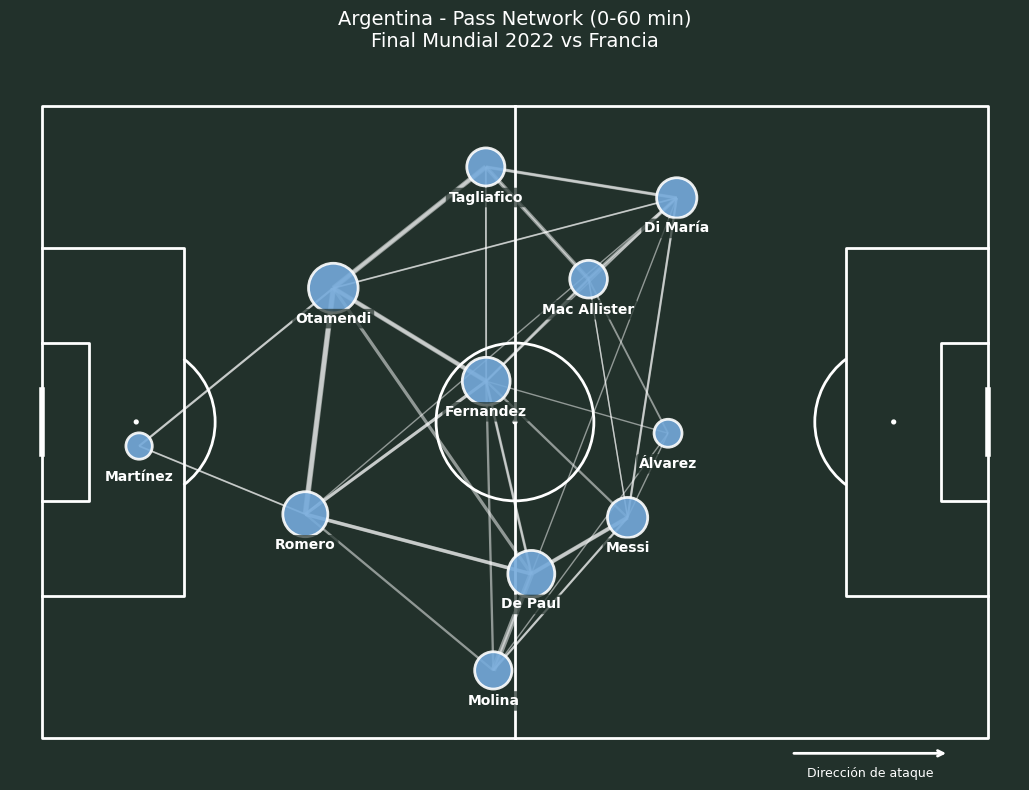

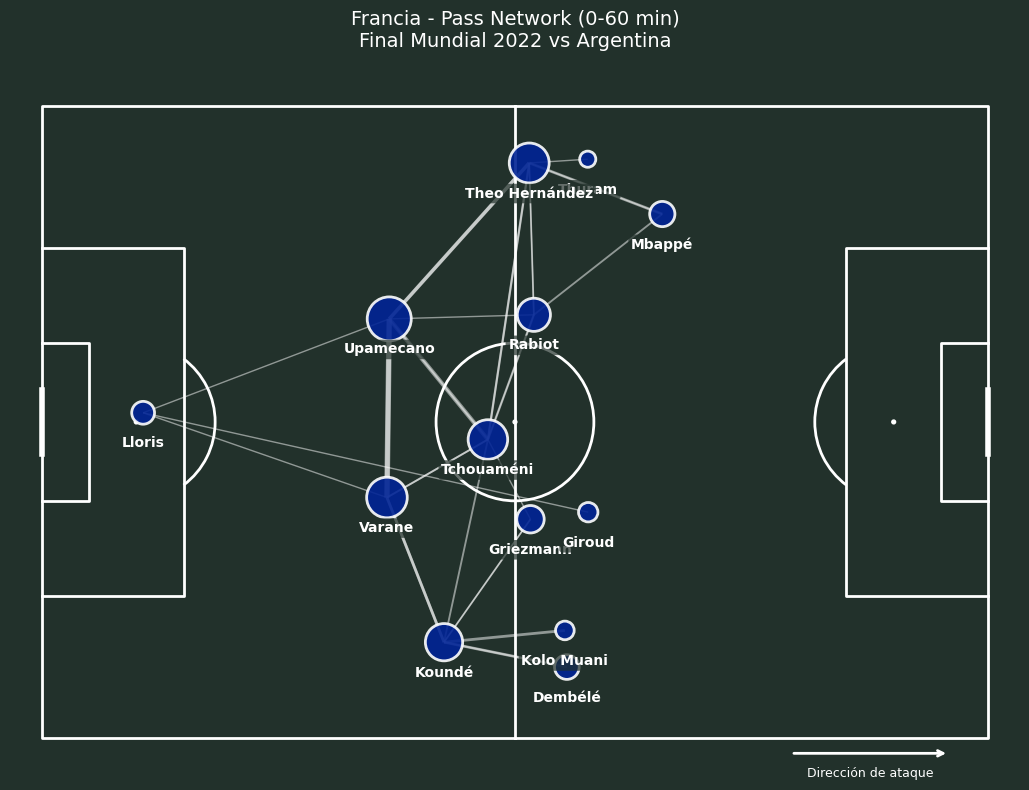

In [33]:
# Argentina
nodos_arg, conexiones_arg = crear_pass_network_v2(events, 'Argentina', max_minuto=60)
fig, ax = plot_pass_network_v2(
    nodos_arg, conexiones_arg,
    color_equipo='#75AADB',
    titulo='Argentina - Pass Network (0-60 min)\nFinal Mundial 2022 vs Francia'
)
plt.savefig('../outputs/figures/pass_network_argentina_v2.png', 
            dpi=150, bbox_inches='tight', facecolor='#22312b')
plt.show()

# Francia
nodos_fra, conexiones_fra = crear_pass_network_v2(events, 'France', max_minuto=60)
fig, ax = plot_pass_network_v2(
    nodos_fra, conexiones_fra,
    color_equipo='#002395',
    titulo='Francia - Pass Network (0-60 min)\nFinal Mundial 2022 vs Argentina'
)
plt.savefig('../outputs/figures/pass_network_francia_v2.png', 
            dpi=150, bbox_inches='tight', facecolor='#002395')
plt.show()

In [34]:
print("=== JUGADORES EN PASS NETWORK ARGENTINA ===")
for _, row in nodos_arg.iterrows():
    print(f"  {obtener_apellido(row['jugador'])}: pos ({row['x_avg']:.0f}, {row['y_avg']:.0f}), eventos: {row['pases_count']}")

print("\n=== JUGADORES EN PASS NETWORK FRANCIA ===")
for _, row in nodos_fra.iterrows():
    print(f"  {obtener_apellido(row['jugador'])}: pos ({row['x_avg']:.0f}, {row['y_avg']:.0f}), eventos: {row['pases_count']}")

=== JUGADORES EN PASS NETWORK ARGENTINA ===
  Mac Allister: pos (69, 22), eventos: 49
  Romero: pos (33, 52), eventos: 70
  Martínez: pos (12, 43), eventos: 24
  Fernandez: pos (56, 35), eventos: 79
  Álvarez: pos (79, 41), eventos: 27
  Messi: pos (74, 52), eventos: 56
  Molina: pos (57, 71), eventos: 48
  Tagliafico: pos (56, 8), eventos: 50
  Otamendi: pos (37, 23), eventos: 85
  De Paul: pos (62, 59), eventos: 76
  Di María: pos (81, 12), eventos: 56

=== JUGADORES EN PASS NETWORK FRANCIA ===
  Rabiot: pos (62, 26), eventos: 38
  Griezmann: pos (62, 52), eventos: 26
  Tchouaméni: pos (57, 42), eventos: 54
  Upamecano: pos (44, 27), eventos: 67
  Lloris: pos (13, 39), eventos: 18
  Koundé: pos (51, 68), eventos: 48
  Mbappé: pos (79, 14), eventos: 22
  Thuram: pos (69, 7), eventos: 9
  Giroud: pos (69, 51), eventos: 13
  Dembélé: pos (67, 71), eventos: 21
  Kolo Muani: pos (66, 66), eventos: 12
  Varane: pos (44, 50), eventos: 57
  Theo Hernández: pos (62, 7), eventos: 55


## Conclusiones del análisis

- **Argentina dominó la posesión** con 80.8% de precisión en pases vs 76.1% de Francia, 
  generando 5.89 xG contra 5.41 de Francia.

- **Enzo Fernández fue el eje del juego argentino** con la mayor cantidad de toques del 
  partido, conectando defensa con ataque desde el mediocampo.

- **Francia tuvo dificultades para progresar** en los primeros 60 minutos, con su pass 
  network concentrado en zona defensiva. La reacción francesa llegó recién con los 
  cambios después del minuto 70.